# Iris Flower Classification — CodeAlpha Data Science Internship

**Objective:** Predict the species of an Iris flower (Setosa / Versicolor / Virginica) using four measurements: sepal length, sepal width, petal length, and petal width.

**Steps:**

1. Data Loading & Exploration
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing (Encoding + Scaling)
4. Train/Test Split
5. Train and compare multiple models
6. Evaluation using the best model (Accuracy, Confusion Matrix, Classification Report)


## 1. Importing the Required Libraries

In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style('whitegrid')
%matplotlib inline

os.makedirs('plots', exist_ok=True)

## 2. Loading the Data

We dropped the `Id` column because it does not provide any useful information for the model; it only represents the row number.

In [21]:
df = pd.read_csv('Iris.csv')
df.drop('Id', axis=1, inplace=True)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [23]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [24]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## 3. Exploratory Data Analysis (EDA)

We will use a **pairplot** to visualize which features can easily distinguish between the different species.

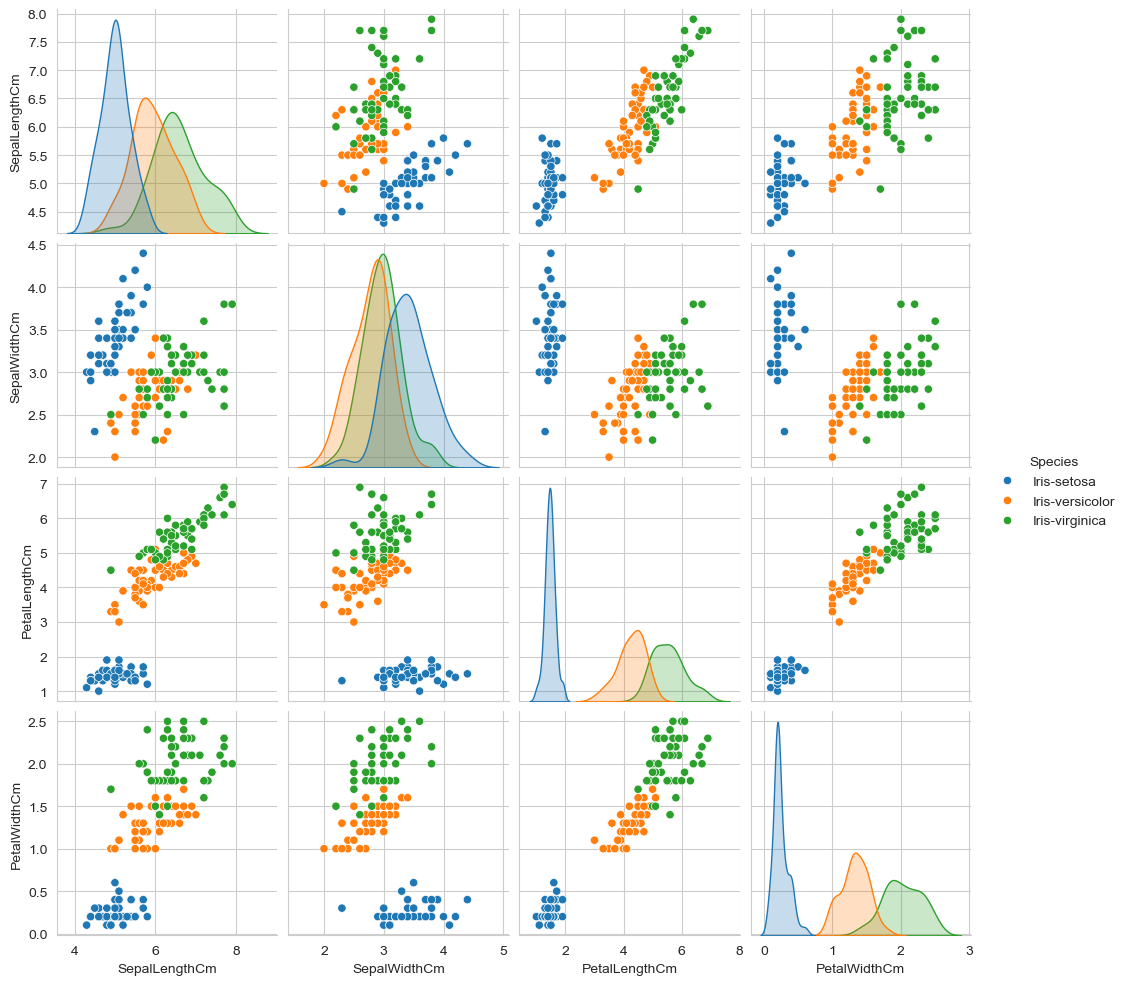

In [25]:
sns.pairplot(df, hue='Species')
plt.savefig('plots/pairplot.png', dpi=100, bbox_inches='tight')
plt.show()

**Observation:** The three species can be almost clearly separated using **petal length** and **petal width** — these two are the most important features.

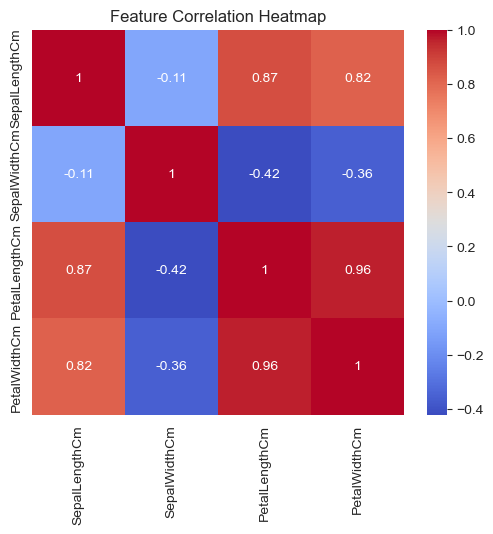

In [26]:
plt.figure(figsize=(6,5))
sns.heatmap(df.drop('Species', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.savefig('plots/correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

* Convert `Species` (text) into numerical values using `LabelEncoder` (`0 = setosa`, `1 = versicolor`, `2 = virginica`).
* Scale the features using `StandardScaler`, because without scaling, the performance of distance-based models such as KNN may be affected.

In [27]:
le = LabelEncoder()
df['Species_encoded'] = le.fit_transform(df['Species'])

X = df.drop(['Species', 'Species_encoded'], axis=1)
y = df['Species_encoded']

print("Classes:", list(le.classes_))
X.head()

Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 5. Train/Test Split

20% of the data is reserved for testing. `stratify=y` is used to ensure that the proportion of each species remains the same in both the training and test sets.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (120, 4) Test shape: (30, 4)


## 6. Train and Compare Multiple Models

We will try four different classification algorithms and compare their performance to determine which one achieves the highest accuracy.

In [29]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.9333
KNN (k=5): 0.9333
Decision Tree: 0.9000
Random Forest: 0.9000


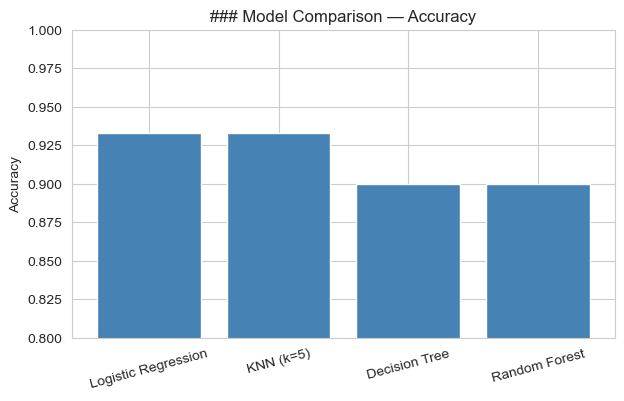

In [30]:
plt.figure(figsize=(7,4))
plt.bar(results.keys(), results.values(), color='steelblue')
plt.ylabel('Accuracy')
plt.title('### Model Comparison — Accuracy')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=15)
plt.savefig('plots/model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Detailed Evaluation Using the Best Model

Best Model: Logistic Regression | Accuracy: 0.9333333333333333


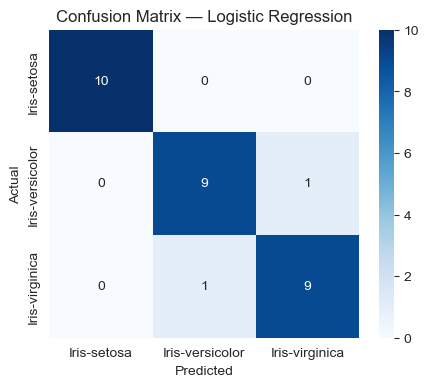

In [31]:
best_name = max(results, key=results.get)
best_model = models[best_name]
print("Best Model:", best_name, "| Accuracy:", results[best_name])

pred = best_model.predict(X_test_s)
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {best_name}')
plt.savefig('plots/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

In [32]:
print(classification_report(y_test, pred, target_names=le.classes_))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



## 8. Conclusion

* The Iris dataset was successfully classified using four measurements with very good accuracy (**~93%+**).
* **Petal length** and **petal width** were the most important features for distinguishing the species, as observed from the pairplot and correlation heatmap.
* **Setosa** was consistently classified with **100% accuracy** because it is linearly separable, while there is some overlap between **Versicolor** and **Virginica**, resulting in a few misclassifications.
* **Logistic Regression** and **KNN** both performed well on this small and clean dataset.

**Future Improvements:** Cross-validation, hyperparameter tuning using `GridSearchCV`, or trying an **SVM** model could potentially improve the results further.